# 1. Dask
---

In [1]:
# Instalar bibliotecas necesarias
!uv pip install dask distributed --quiet  # Para trabajar con Dask
!uv pip install pyngrok --quiet  # Para exponer el dashboard de Dask
!uv pip install kagglehub # Para extraer el dataset directamente desde Kaggle

Checked 1 package in 12ms


In [2]:
# Importar librerías
from dask.distributed import Client, LocalCluster
from pyngrok import ngrok
import multiprocessing
import matplotlib.pyplot as plt
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

## 1.0. Exponer el Dashboard de Dask con ngrok y configuración del clúster en modo CPU


In [3]:
# Función para exponer el dashboard de Dask con ngrok
def expose_dashboard(cluster):
    ngrok.set_auth_token("3DGUSrNgMvLKPTUmNUW5yTWO6gG_K8JaZSLeymSDNRoijoV1")
    public_url = ngrok.connect(
        "8787"
    )  # Puerto por defecto del dashboard de Dask
    print(f"El dashboard de Dask está disponible en: {public_url}")
    return public_url


def setup_cluster(mode="cpu"):
    if mode == "cpu":
        # Configuración para uso de CPU
        num_cpus = int(
            multiprocessing.cpu_count() // 2
        )  # Menos núcleos de la CPU para evitar saturación
        cluster = LocalCluster(n_workers=num_cpus, threads_per_worker=2)
    else:
        raise ValueError("Modo no válido")

    # Conectar al cluster
    client = Client(cluster)
    print(client)  # Mostrar información del cliente
    expose_dashboard(cluster)  # Exponer el dashboard
    return client


# Modo CPU
client_cpu = setup_cluster(mode="cpu")

<Client: 'tcp://127.0.0.1:37001' processes=10 threads=20, memory=31.04 GiB>
El dashboard de Dask está disponible en: NgrokTunnel: "https://13b3-88-98-121-210.ngrok-free.app" -> "http://localhost:8787"


2026-05-04 18:59:29,542 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle c18e3034f3c9cc89925a300b877e28d9 initialized by task ('shuffle-transfer-c18e3034f3c9cc89925a300b877e28d9', 99) executed on worker tcp://127.0.0.1:37017
2026-05-04 18:59:55,111 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle c18e3034f3c9cc89925a300b877e28d9 deactivated due to stimulus 'task-finished-1777913995.1078393'
2026-05-04 18:59:56,429 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4d87ef689a49870469c80b255136e005 initialized by task ('shuffle-transfer-4d87ef689a49870469c80b255136e005', 67) executed on worker tcp://127.0.0.1:43005
2026-05-04 19:00:27,057 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4d87ef689a49870469c80b255136e005 deactivated due to stimulus 'task-finished-1777914027.0566168'
2026-05-04 19:00:29,457 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 031309cfe0d75cb0a9f0662bf02b2ffe initialized by task ('shuffle-transfer-031309cfe0d7

## 1.1. Cargar y limpiar datos

Vamos a trabajar con el dataset de Kaggle **"NYC parking tickets for 2014 to 2017"** proporcionado en https://www.kaggle.com/datasets/new-york-city/nyc-parking-tickets

Realizaremos una serie de preprocesamientos y revisión de errores para peparar los datos para posteriores análisis exhaustivos.

1. Cargar cada archivo CSV en un dataframe de Dask distinto (4 en total) para inspeccionarlos y verificar cualquier problema en cada caso. **Revisa y evidencia los siguientes problemas:**

   - Problema: los tipos de datos inferidos automáticamente por Dask no son correctos.
   - Problema: no todos los archivos tienen las mismas columnas; si simplemente combinamos los 4 datasets, terminaremos con muchos valores nulos.

In [4]:
import dask.dataframe as dd
import os
import kagglehub

# Descargamos el dataset

dataset_name = "new-york-city/nyc-parking-tickets"
path = kagglehub.dataset_download(dataset_name)
os.makedirs(path, exist_ok=True)

# Cargamos cada archivo en un DataFrame de Dask distinto
tickets14 = dd.read_csv(
    os.path.join(
        path,
        "Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv",
    ),
    assume_missing=True,
    sample=10000,
)
print(f"Columnas y Tipos de datos 2014:\n{tickets14.dtypes}")
print(f"Número de columnas: {len(set(tickets14.columns))}")
print("-" * 60)
print()

tickets15 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2015.csv"),
    assume_missing=True,
    sample=10000,
)
print(f"Columnas y Tipos de datos 2015:\n{tickets15.dtypes}")
print(f"Número de columnas: {len(set(tickets15.columns))}")
print("-" * 60)
print()

tickets16 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2016.csv"),
    assume_missing=True,
    sample=10000,
)
print(f"Columnas y Tipos de datos 2016:\n{tickets16.dtypes}")
print(f"Número de columnas: {len(set(tickets16.columns))}")
print("-" * 60)
print()

tickets17 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2017.csv"),
    assume_missing=True,
    sample=10000,
)
print(f"Columnas y Tipos de datos 2017:\n{tickets17.dtypes}")
print(f"Número de columnas: {len(set(tickets17.columns))}")
print("-" * 60)

Columnas y Tipos de datos 2014:
Summons Number                       float64
Plate ID                              string
Registration State                    string
Plate Type                            string
Issue Date                            string
Violation Code                       float64
Vehicle Body Type                     string
Vehicle Make                          string
Issuing Agency                        string
Street Code1                         float64
Street Code2                         float64
Street Code3                         float64
Vehicle Expiration Date              float64
Violation Location                   float64
Violation Precinct                   float64
Issuer Precinct                      float64
Issuer Code                          float64
Issuer Command                       float64
Issuer Squad                         float64
Violation Time                        string
Time First Observed                  float64
Violation County       

In [5]:
tickets = {
    "tickets14": tickets14,
    "tickets15": tickets15,
    "tickets16": tickets16,
    "tickets17": tickets17,
}

# Comparar columnas entre todos los pares de DataFrames
for name1, df1 in tickets.items():
    for name2, df2 in tickets.items():
        if name1 >= name2:
            continue
        if set(df1.columns) != set(df2.columns):
            print(f"Diferencia de columnas entre {name1} y {name2}")

Diferencia de columnas entre tickets14 y tickets17
Diferencia de columnas entre tickets15 y tickets17
Diferencia de columnas entre tickets16 y tickets17


In [6]:
try:
    # Intenta ejecutar la operación que causa el conflicto de tipos
    display(tickets14.head())
except ValueError as e:
    # Captura el error específico y lo imprime sin detener la celda
    print(f"Bypass del error de tipos detectado:\n{e}")

/home/pyros05/Escritorio/cid-upct/Prácticas/3º Curso/2º Cuatrimestre/PPD/Entregables/Entregable_4/.venv/lib/python3.12/site-packages/dask/dataframe/io/csv.py:76: DtypeWarning: Columns (0: Issuer Squad, 1: Violation Legal Code, 2: Violation Post Code, 3: Violation Description) have mixed types. Specify dtype option on import or set low_memory=False.
  df = reader(bio, **kwargs)


Bypass del error de tipos detectado:
Mismatched dtypes found in `pd.read_csv`/`pd.read_table`.

+-----------------------+--------+----------+
| Column                | Found  | Expected |
+-----------------------+--------+----------+
| House Number          | str    | float64  |
| Issuer Command        | str    | float64  |
| Issuer Squad          | object | float64  |
| Time First Observed   | str    | float64  |
| Violation Description | str    | float64  |
| Violation Legal Code  | object | float64  |
| Violation Post Code   | object | float64  |
+-----------------------+--------+----------+

The following columns also raised exceptions on conversion:

- House Number
  ValueError("could not convert string to float: '67-21'")
- Issuer Command
  ValueError("could not convert string to float: 'T730'")
- Issuer Squad
  ValueError("could not convert string to float: 'L'")
- Time First Observed
  ValueError("could not convert string to float: '1134P'")
- Violation Description
  ValueError

2026-05-04 18:57:58,961 - distributed.worker - ERROR - Compute Failed
Key:       ('read-csv-99556cf1f9e5c9d033e9fe05e4c484c3', 0)
State:     executing
Task:  <Task ('read-csv-99556cf1f9e5c9d033e9fe05e4c484c3', 0) _read_csv(..., ...)>
Exception: 'ValueError(\'Mismatched dtypes found in `pd.read_csv`/`pd.read_table`.\\n\\n+-----------------------+--------+----------+\\n| Column                | Found  | Expected |\\n+-----------------------+--------+----------+\\n| House Number          | str    | float64  |\\n| Issuer Command        | str    | float64  |\\n| Issuer Squad          | object | float64  |\\n| Time First Observed   | str    | float64  |\\n| Violation Description | str    | float64  |\\n| Violation Legal Code  | object | float64  |\\n| Violation Post Code   | object | float64  |\\n+-----------------------+--------+----------+\\n\\nThe following columns also raised exceptions on conversion:\\n\\n- House Number\\n  ValueError("could not convert string to float: \\\'67-21\\\'")\

En las celdas anteriores hemos podido evidenciar ambos problemas:

   - En primer lugar, tenemos que el CSV con la información del dataset para 2017 tiene menos
     columnas que los demás por lo que nos tendremos que adecuar a este para que no hayan muchos
     valores nulos en aquellas columnas que este fichero no tiene, para ello combinaremos los
     datasets quedándonos solo con las columnas comunes entre ellos.
   - En segundo lugar, podemos ver en el error anterior, que `Dask` no ha conseguido inferir
     correctamente el tipo de dato de algunas columnas como **House Number, Time First Observed**
     y **Violation Legal Code**, para solucionar esto especificaremos al framework el tipo de dato
     a utilizar a la hora de cargar los datos de las diferentes columnas.

2. Por lo tanto, antes de combinar los datasets, extraerás solo las columnas comunes entre los 4 archivos

Esto se puede hacer de varias maneras, pero una de las más sencillas es utilizar el método `intersection`.
Dado que este método funciona con conjuntos de Python, primero convierte la lista de columnas a sets.

```python
common_cols = list(set(tickets14.columns).intersection(tickets15.columns, tickets16.columns, tickets17.columns))
```

In [7]:
# Obtenemos las columnas comunes entre los DataFrames
common_cols = list(
    set(tickets14.columns).intersection(
        tickets15.columns, tickets16.columns, tickets17.columns
    )
)

3. Especifica el esquema de tipo de datos deseado para el DataFrame de Dask: convierte todas las columnas comunes a `'str'`.

- Ahora si, vamos a especificar el esquema del tipo de datos y no habrá así ningún problema con la incorrecta inferencia de tipos por parte del framework.

In [8]:
# Convertimos todas las columnas comunes a string y cargamos solamente estas
data_types = {col: "str" for col in common_cols}

tickets14 = dd.read_csv(
    os.path.join(
        path,
        "Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv",
    ),
    assume_missing=True,
    usecols=common_cols,
    dtype=data_types,
)
tickets15 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2015.csv"),
    assume_missing=True,
    usecols=common_cols,
    dtype=data_types,
)
tickets16 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2016.csv"),
    assume_missing=True,
    usecols=common_cols,
    dtype=data_types,
)
tickets17 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2017.csv"),
    assume_missing=True,
    usecols=common_cols,
    dtype=data_types,
)

4. Ahora que has limpiado los datos, carga los 4 archivos en un único DataFrame de Dask y hazlo persistente en RAM para un procesamiento posterior.

- Verifica el dashboard y espera hasta que todos los datos estén cargados en RAM. Esto puede tardar varios minutos.
- Toma una captura de pantalla de tu Dask Dashboard durante el proceso de carga e insértala en tu notebook de entrega. Revisa los bytes almacenados por cada worker y explica el concepto de "Spilling to disk", comentando si te encuentras en esta situación.
- Verifica y anota el número de particiones del DataFrame.
- Verifica y anota el número de filas, columnas y el tamaño en RAM del DataFrame.

In [9]:
# Cargamos los DataFrames en uno único
df = dd.concat([tickets14, tickets15, tickets16, tickets17], axis=0)

# Para hacer el dataframe persistente en memoria debemos hacer:
df = df.persist()

# Para el dataset en RAM hacemos:
print(df.info())

print(f"Nº de particiones: {df.npartitions}")
n_filas = df.shape[0].compute()  # N_FILAS
n_columnas = df.shape[1]  # N_COLUMNAS

print(f"\nNº de Filas: {n_filas}\nNº de columnas: {n_columnas}")
print(
    f"Tamaño aproximado en RAM (GBytes): {df.memory_usage(deep=True).sum().compute() / 1024**3}"
)

<class 'dask.dataframe.dask_expr.DataFrame'>
Columns: 43 entries, Summons Number to Double Parking Violation
dtypes: string(43)None
Nº de particiones: 138


2026-05-04 18:58:52,783 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 1.94 GiB -- Worker memory limit: 3.10 GiB



Nº de Filas: 42339438
Nº de columnas: 43
Tamaño aproximado en RAM (GBytes): 20.111379859037697


In [10]:
# Esquema de datos correctamente definidos
print(df.dtypes)

Summons Number                       string
Plate ID                             string
Registration State                   string
Plate Type                           string
Issue Date                           string
Violation Code                       string
Vehicle Body Type                    string
Vehicle Make                         string
Issuing Agency                       string
Street Code1                         string
Street Code2                         string
Street Code3                         string
Vehicle Expiration Date              string
Violation Location                   string
Violation Precinct                   string
Issuer Precinct                      string
Issuer Code                          string
Issuer Command                       string
Issuer Squad                         string
Violation Time                       string
Time First Observed                  string
Violation County                     string
Violation In Front Of Or Opposit

Podemos observar la correcta definición del tipo de datos mediante el esquema definido, para esta primera carga hemos utilizado `string` como tipo de dato para todas las columnas.

Por otro lado:

1. Tenemos que, en la lectura, Dask ha definido 138 particiones para el almacenamiento distribuido(ficticio) de los datos del dataset.

2. Hay 42.339.438 filas, 43 columnas(atributos) y el tamaño en RAM del DataFrame es de 20.11 GBytes.

### Dask Dashboard durante el proceso de carga:

1. Diferentes tareas de procesamiento del dataset para su carga en los diferentes nodos del clúster:

   ![](<attachment:Captura desde 2026-05-04 13-19-59.png>)

2. Métricas de trabajo de los distintos workers del clúster:

   Observar el:

   - Gran uso de CPU para procesar todos los datos
   - El incremento secuencial del uso de la memoria RAM donde se esta almacenando el dataset
   - El comienzo del Spilling to Disk que se puede apreciar en la columna 11.
   - Número de bytes almacenados por cada worker que se puede apreciar en la columna 5.

   ![](<attachment:Captura desde 2026-05-04 13-22-50-2.png>)

3. Spilling to Disk y muestral del Dashboard Final

   - Aquí se puede ver claramente como nuestros workers han tenido que echar mano del mecanismo de spilling, esto ocurre porque estos intentan cargar o procesar más datos de los que caben en su memoria RAM, y como resultado tienen que usar el disco como almacenamiento temporal de estos datos que no caben.
   
   - Observar que se han llevado **14.86 GBytes** de datos al disco mediante este mecanismo.

   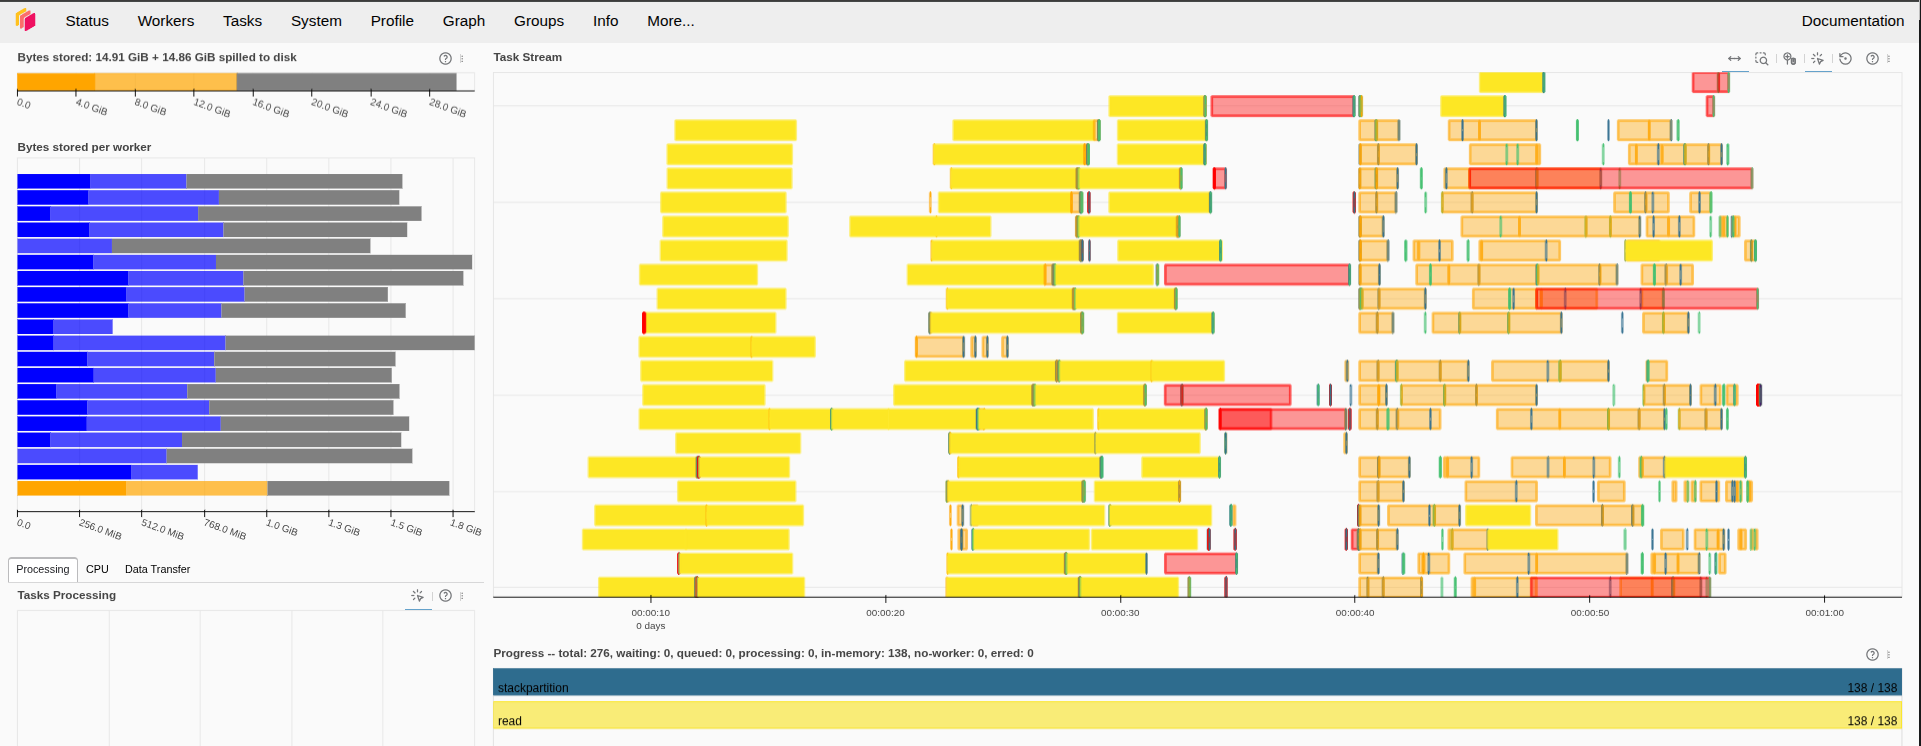

4. Tiempo necesitado para la carga de todo el dataset mediante el clúster de "cpus"

   El dataset con sus 138 particiones ha sido cargado completamente en RAM y, temporalmente, en disco en **aproximadamente un minuto**, veremos próximamente si con otros métodos conseguimos aumentar la eficiencia.
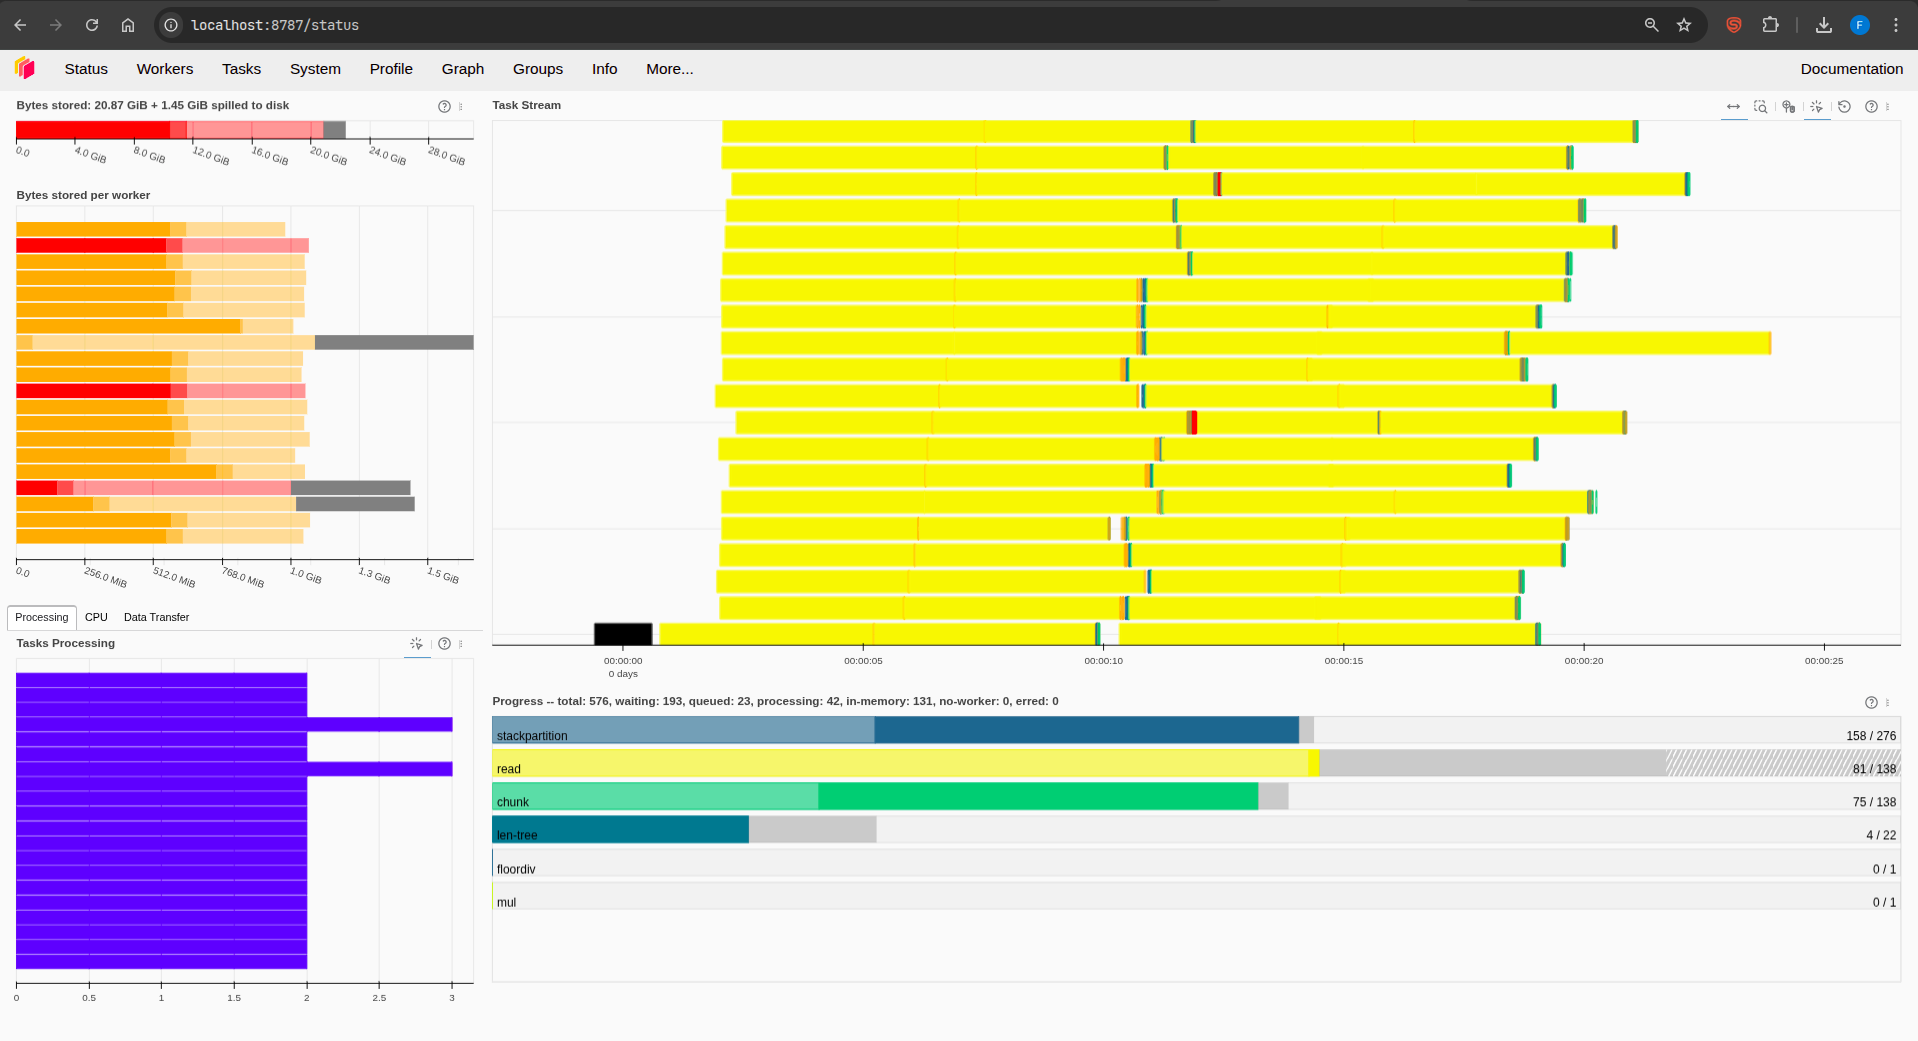
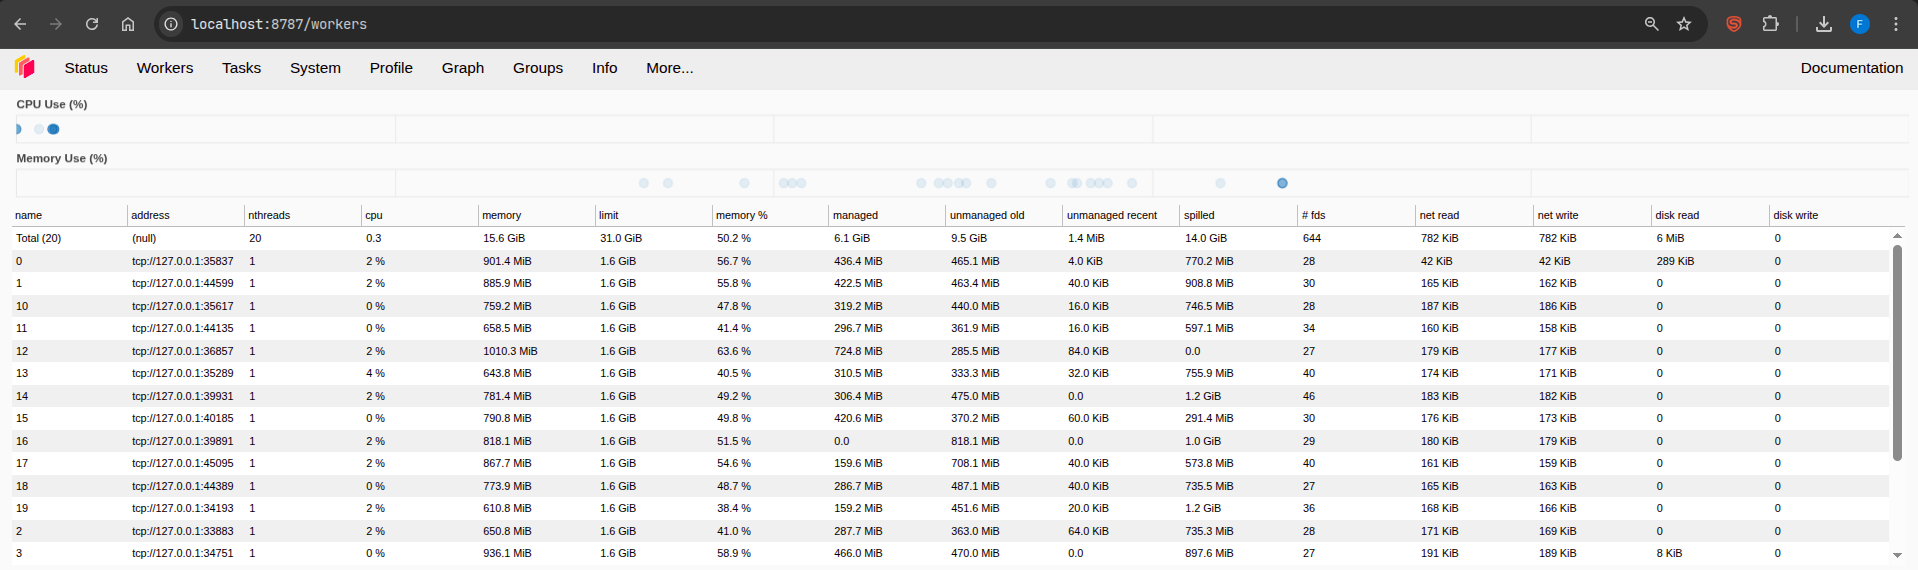

## 1.2. Calcular algunos filtros

1. Calcula el condado de NYC que recibió más multas durante el periodo de estudio.

In [11]:
# Calcular el condado con más multas usando value_counts
county_with_most_violations = (
    df["Violation County"].value_counts().nlargest(1).compute()
)

county = county_with_most_violations.index[0]
n_vio = county_with_most_violations.values[0]

print(
    f"El condado con más multas durante el periodo de estudio fue: {county} con {n_vio} multas."
)

El condado con más multas durante el periodo de estudio fue: NY con 14630069 multas.


In [12]:
del county_with_most_violations

Para encontrar el condado con más multas, seguimos estos pasos:
1. **Contamos** el número de multas por condado mediante `value_counts()`.
2. **Identificamos** el condado con el mayor número de múltas mediante `.nlargest(1)`.
3. **Mostramos** el condado con más multas y el número de multas registradas.

Siguiendo estos pasos encontramos que el condado de NYC con más multas es: **NY**.

---
2. Calcula los 10 coches que recibieron más multas durante el periodo de estudio. Utiliza la columna `'Plate ID'` para identificar cada coche.

In [13]:
# Seleccionamos 'Plate ID' que contiene el número de matrícula y contamos el número de multas en cada
# matrícula y nos quedamos con los 11 valores más altos porrque el primero se asocia a matrícula en
# blanco.
top_10_plates = (
    df["Plate ID"].value_counts(split_every=4).nlargest(11).compute()
)

# Imprimimos las 10 matrículas con el mayor número de multas
for i, count_vio in enumerate(top_10_plates):
    print(
        f"El {i}º coche con más multas: {top_10_plates.index[i]} -> {count_vio}"
    )

2026-05-04 19:00:22,920 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 1.97 GiB -- Worker memory limit: 3.10 GiB


El 0º coche con más multas: BLANKPLATE -> 56717
El 1º coche con más multas: 47603MD -> 4003
El 2º coche con más multas: 49781MA -> 3534
El 3º coche con más multas: 2028685 -> 3497
El 4º coche con más multas: AN917T -> 3312
El 5º coche con más multas: 96087MA -> 3261
El 6º coche con más multas: 75225JW -> 3217
El 7º coche con más multas: 49839JG -> 3204
El 8º coche con más multas: AP300F -> 3190
El 9º coche con más multas: 62546JM -> 3169
El 10º coche con más multas: 16213TC -> 3152


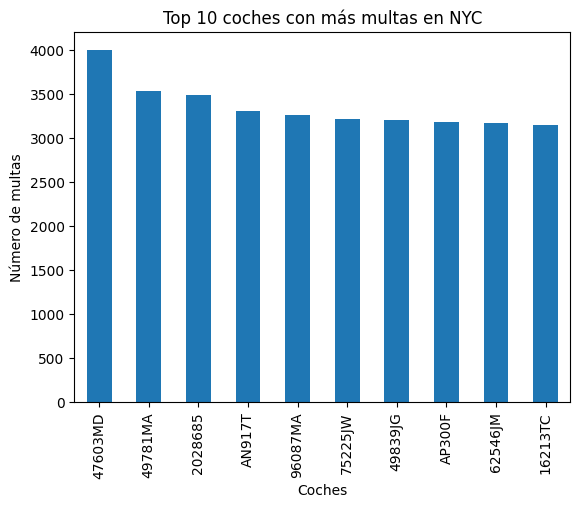

In [14]:
# Graficamos las 10 matrículas con el mayor número de multas mediante una gráfica de barras
top_10_plates[1:].plot(
    kind="bar",
    title="Top 10 coches con más multas en NYC",
    xlabel="Coches",
    ylabel="Número de multas",
)
plt.show()

In [15]:
del top_10_plates

Para encontrar los 10 coches con más multas, seguimos estos pasos:

1. **Contamos** el número de multas por matrícula (`'Plate ID'`) y **Ordenamos** esas matrículas a partir de su conteo de manera descendente.
2. **Identificamos** las 10 matrículas con el mayor número de multas.
3. **Mostramos** las 10 matrículas con más multas y el número de multas registradas para cada una.
4. **Graficamos** los resultados en un gráfico de barras.

Siguiendo estos pasos observamos que:

- Las personas suelen tener bastantes multas cuando no tienen aún matriculado el coche.
- El coche con más infracciones cometidas durante el periodo de estudio es el coche con matrícula **47603MD**.

---

3. Distribución de multas por mes (agregación temporal): Determinar el número total de multas emitidas en cada mes a lo largo del periodo y descubrir qué mes presenta la mayor cantidad de infracciones (para identificar posibles tendencias estacionales). (Pista: La columna de fecha de emisión Issue Date incluye fecha/hora de la multa): df['Issue Date'].dt.month para obtener el mes).


In [ ]:
# Convertimos 'Issue Date' a datetime
df["Issue Date"] = dd.to_datetime(df["Issue Date"], errors="coerce")

# Extraemos el mes de la columna 'Issue Date' y generamos una nueva columna en el datframe con el
df["Issue Month"] = df["Issue Date"].dt.month

# Mediante 'Issue Month' realizamos el conteo y ordenamos de forma descendente
monthly_counts = (
    df["Issue Month"].value_counts().compute().sort_values(ascending=False)
)

# Mostramos la distribución de multas y el mes con más infracciones cometidas
print("Distribución de multas por mes:")
print(monthly_counts)

print(
    f"\nEl mes con más infracciones es: {monthly_counts.index[0]} con {monthly_counts.values[0]} multas"
)

Distribución de multas por mes:
Issue Month
10    3987212
3     3852356
5     3840294
1     3809913
9     3758123
6     3710541
4     3602097
11    3483306
8     3455617
12    3055935
2     3054514
7     2729530
Name: count, dtype: int64

El mes con más infracciones es: 10 con 3987212 multas


Para obtener la distribución de multas por mes y el mes con más multas seguimos estos pasos:

1. **Convertimos** la columna 'Issue Date' a formato datetime.
2. **Extraemos** el mes de la columna 'Issue Date' y creamos una nueva columna llamada 'Issue Month'.
3. **Contamos** el número de multas por cada mes.
4. **Identificamos** el mes con el mayor número de multas escogiendo el 1º de ellos dado que hemos ordenado de manera descendente.
5. **Mostramos** la distribución de multas por mes y el mes con el mayor número de infracciones.

Podemos observar que, durante el periodo de estudio, **Octubre** fue el mes con más infracciones registradas.

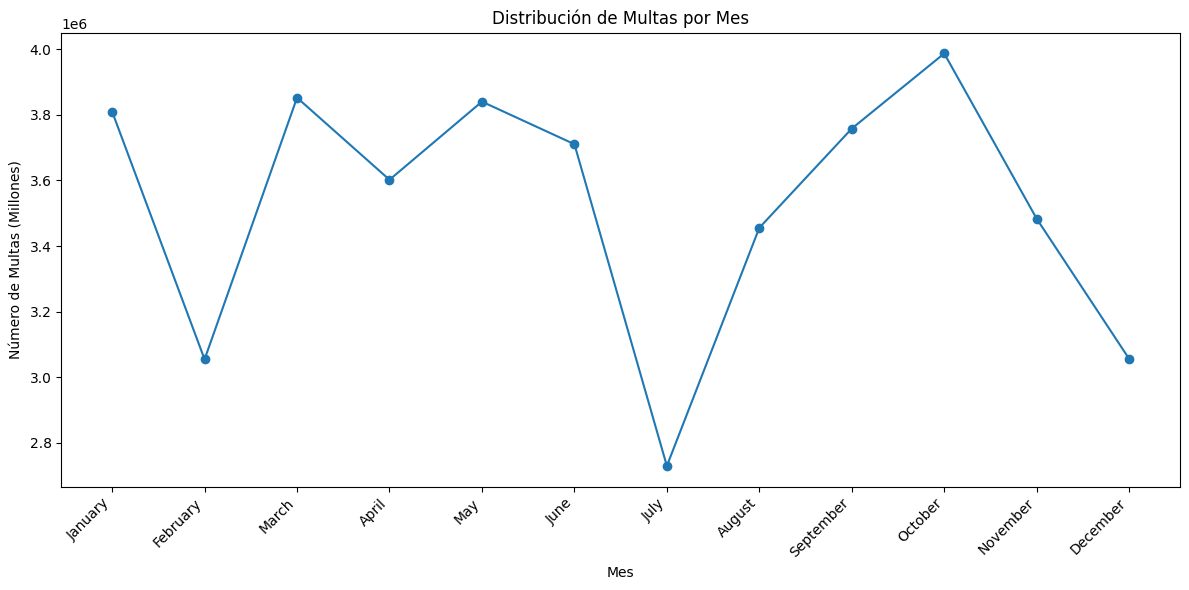

In [17]:
import calendar

# Ordenamos por índice
monthly_counts = monthly_counts.sort_index()

# Mapeamos los índices a nombres de meses en inglés
month_names = [calendar.month_name[i] for i in monthly_counts.index]


plt.figure(figsize=(12, 6))
plt.plot(month_names, monthly_counts.values, marker="o")
plt.xlabel("Mes")
plt.ylabel("Número de Multas (Millones)")
plt.title("Distribución de Multas por Mes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
del monthly_counts

Visualizando la gráfica de la distribución de multas podemos observar claramente como se reducen considerablemente en los meses vacacionales como Julio y Diciembre, por otro lado, se observa una constante durante los meses que se dan entre Navidad y Verano, por último, comentar que después de las vacaciones de verano se da un aumento progresivo de las infracciones llegando a su pico de **Octubre**, esto podríamos llegar a achacarlo a esa ansiedad que se produce en las personas a la vuelta de las vacaciones lo que les puede llevar a cometer más infracciones de lo normal.

---

4. Horas del día con más multas (patrón diario): Analizar en qué horas del día se emiten más multas, identificando las horas pico de sanciones. (Pista: basándote en "Violation Time" extrae la hora del día de cada registro. Crea tu propia funcion "extract_hour" para obtener la hora - el formato es HORAMINUTOA/P, por ejemplo 0710P serían las 19:10. 0810A serían las 8:10-. Utiliza el método "map" para aplicar tu función a la entrada).


In [19]:
def extract_hour(time_str):
    if not isinstance(time_str, str):
        return None  # Manejar valores no válidos

    time_str = time_str.strip()
    if not time_str:
        return None

    period = time_str[-1].upper()
    time_str = time_str[:-1]

    try:
        hour = int(time_str[:2])
    except ValueError:
        return None

    if period == "P" and hour != 12:
        hour += 12
    elif period == "A" and hour == 12:
        hour = 0  # Medianoche

    return hour

In [20]:
# Aplicamos la función extract_hour definida a la columna 'Violation Time' para extraer
# la hora de cada tiempo
df["Violation Extract Hour"] = df["Violation Time"].map(
    extract_hour, meta=("Violation Time", "int64")
)

# Realizamos el conteo para cada hora y ordenamos de manera descendente
hourly_counts = (
    df["Violation Extract Hour"]
    .value_counts()
    .compute()
    .sort_values(ascending=False)
)

print("\nLas 10 horas pico con más infracciones son:")
for i in range(11):
    print(f"\nLas {hourly_counts.index[i]}h con {hourly_counts.iloc[i]} multas")


Las 10 horas pico con más infracciones son:

Las 9.0h con 4499583 multas

Las 11.0h con 4402639 multas

Las 13.0h con 4132527 multas

Las 8.0h con 3886120 multas

Las 12.0h con 3699299 multas

Las 10.0h con 3678650 multas

Las 14.0h con 3540660 multas

Las 15.0h con 2526664 multas

Las 16.0h con 2362957 multas

Las 7.0h con 2111441 multas

Las 17.0h con 1705422 multas


Con la función definida `extract_hour(time_str)` extraemos la hora de un string de tiempo, extrae la hora en formato de 24 horas, manejando los casos AM/PM.

A continuación, realizamos el siguiente procesamiento en el DataFrame:

1.  **Extraemos la hora:** Aplicamos la función `extract_hour` a la columna 'Violation Time' para crear una nueva columna, 'Violation Extract Hour'.  Esto nos da la hora en que se emitió cada multa.
2.  **Contamos** el número de multas para cada hora.
3.  **Ordenamos** las horas por el número de multas de forma descendente.
4.  **Mostramos** las 10 horas pico con más multas y el número de multas registradas para cada una.
5.  **Creamos** un gráfico de barras para mostrar la distribución del número de multas por hora, previamente ordenamos por índice(horas).

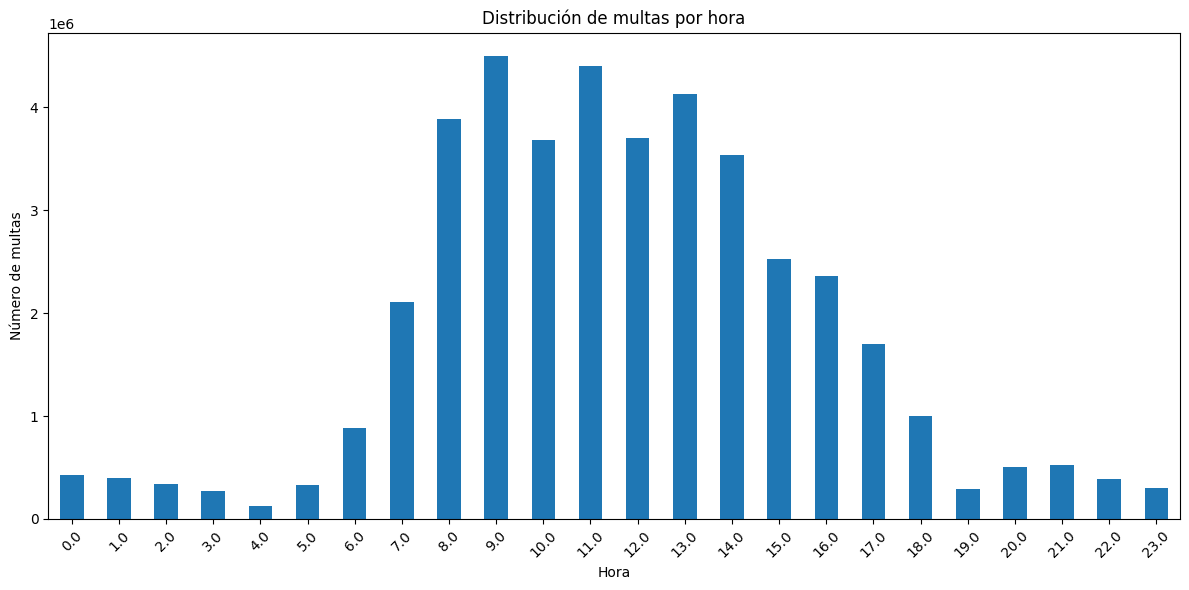

In [21]:
hourly_counts = hourly_counts.sort_index()

# Creamos el gráfico de barras
plt.figure(figsize=(12, 6))
hourly_counts.iloc[:24].plot(kind="bar")
plt.title("Distribución de multas por hora")
plt.xlabel("Hora")
plt.ylabel("Número de multas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Visualizando la gráfica de la distribución de multas por hora podemos observar claramente que las horas más controversiales son las del inicio de la mañana donde las personas están de camino al trabajo o están realizando trámites como papeleo, visitas al médico o la dejada de los niños en la escuela. La hora pico de multas sucede a las **9 de la mañana**.

In [22]:
del hourly_counts

---

5. Tipos de infracción más comunes: Encontrar cuáles son las infracciones de estacionamiento más frecuentes en NYC.


In [23]:
# Realizamos el conteo de multas por cada tipo de'Violation Description', ordenamos y nos quedamos con las 10 más frecuentes
violation_counts = (
    df["Violation Description"].value_counts(sort=True).nlargest(10).compute()
)

# Mostramos los resultados
print("Las 10 infracciones de estacionamiento más frecuentes son:")
print(violation_counts.head(10))

Las 10 infracciones de estacionamiento más frecuentes son:
Violation Description
21-No Parking (street clean)      4954662
38-Failure to Display Muni Rec    4833587
PHTO SCHOOL ZN SPEED VIOLATION    3583078
14-No Standing                    3244603
37-Expired Muni Meter             2800752
FAILURE TO STOP AT RED LIGHT      2161754
20A-No Parking (Non-COM)          1881504
71A-Insp Sticker Expired (NYS)    1765219
40-Fire Hydrant                   1573012
69-Failure to Disp Muni Recpt      957268
Name: count, dtype: int64[pyarrow]


Para encontrar las infracciones de estacionamiento más frecuentes seguimos estos pasos:

1.  **Contamos** el número de multas para cada tipo de 'Violation Description'.
2.  **Ordenamos** los tipos de infracción por el número de multas de forma descendente.
3.  **Seleccionamos** los 10 tipos de infracción más frecuentes.
4.  **Mostramos** los resultados.

Podemos observar que, durante el periodo de estudio, el tipo de multa más común es: **21-No Parking (street clean)** con 4,954,662 multas.

Resumen de las 10 infracciones más frecuentes:

1.  **21-No Parking (street clean):** 4,954,662 multas. La infracción más común, relacionada con el apacamiento en zona prohibida.
2.  **38-Failure to Display Muni Rec:** 4,833,587 multas. No mostrar el recibo municipal.
3.  **PHTO SCHOOL ZN SPEED VIOLATION:** 3,583,078 multas. Infracción por exceso de velocidad en zona escolar.
4.  **14-No Standing:** 3,244,603 multas. Prohibido detenerse.
5.  **37-Expired Muni Meter:** 2,800,752 multas. Expiración del parquímetro municipal.
6.  **FAILURE TO STOP AT RED LIGHT:** 2,161,754 multas. No detenerse como semáforo en rojo.
7.  **20A-No Parking (Non-COM):** 1,881,504 multas. Prohibido estacionar (no comercial).
8.  **71A-Insp Sticker Expired (NYS):** 1,765,219 multas. Calcomanía de inspección expirada (NYS).
9.  **40-Fire Hydrant:** 1,573,012 multas. Estacionar cerca de una boca de incendios.
10. **69-Failure to Disp Muni Recpt:** 957,268 multas. No mostrar el recibo municipal.

In [24]:
del violation_counts

---

6. Zonas con mayor número de multas: Identificar las ubicaciones de la ciudad con más infracciones registradas (e.g., Calle).

In [25]:
# Realizamos el conteo de multas por cada calle de NYC, ordenamos y nos quedamos
# con las 10 que son más propensas a que hayan multas
street_counts = df["Street Name"].value_counts(sort=True).nlargest(10).compute()

# Mostramos los resultados
print("Las 10 calles con más multas son:")
print(street_counts.head(10))

Las 10 calles con más multas son:
Street Name
Broadway         859474
3rd Ave          650506
5th Ave          414020
Madison Ave      394063
Lexington Ave    335943
2nd Ave          313403
1st Ave          294659
7th Ave          264017
Queens Blvd      243205
8th Ave          235267
Name: count, dtype: int64[pyarrow]


Para identificar las ubicaciones con mayor número de multas he seleccionado, específicamente, el atributo 'Street Name' que indica el nombre de la calle donde se cometió la infracción, durante el procesamiento seguimos estos pasos:

1.  **Contamos** el número de multas para cada calle en la columna 'Street Name'.
2.  **Ordenamos** las calles por el número de multas de forma descendente.
3.  **Seleccionamos** las 10 calles con el mayor número de multas.
4.  **Mostramos** los resultados.

Podemos observar que, durante el periodo de estudio, la calle con más infracciones registradas es: **Broadway** con 859.474 multas.

In [26]:
del street_counts